## To increase the number of data points by augmenting through shifting in wavelength and adding noise.

In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [8]:
# import the original data frame built from JADES grism and medium resolution spectra
combined_df = pd.read_pickle("../data/dataset_DR4.pkl")
combined_df.keys()

Index(['id', 'ra', 'dec', 'field', 'wavelength_high', 'flux_high',
       'flux_high_err', 'flux_high_smoothed', 'flux_high_smoothed_err',
       'wavelength_low', 'flux_low', 'flux_low_err', 'filename1', 'filename2',
       'filename3', 'filename4', 'z'],
      dtype='object')

In [9]:
def report_wavelength_ranges_max(df):
    """
    Prints the min and max wavelength range for both low-res and high-res spectra in the DataFrame.
    
    Args:
        df: pandas DataFrame with columns 'wavelength_low' and 'wavelength_high'.
    """
    def get_range(colname):
        min_waves = []
        max_waves = []
        for row in df[colname]:
            arr = np.array(row)
            min_waves.append(arr.min())
            max_waves.append(arr.max())
        return np.min(min_waves), np.max(max_waves)

    low_min, low_max = get_range("wavelength_low")
    high_min, high_max = get_range("wavelength_high")

    print(f"Low-res wavelength range:  {low_min:.3f} – {low_max:.3f} μm")
    print(f"High-res wavelength range: {high_min:.3f} – {high_max:.3f} μm")
    
report_wavelength_ranges_max(combined_df)

Low-res wavelength range:  0.700 – 5.452 μm
High-res wavelength range: 0.700 – 5.452 μm


In [10]:
def count_nan_stats(df, label=""):
    import numpy as np

    print(f"\n=== Strict NaN Stats for {label} ===")
    print(f"Total rows: {len(df)}")

    columns_to_check = [
        'ra', 'dec', 'field',
        'wavelength_low', 'flux_low', 'flux_low_err',
        'wavelength_high', 'flux_high', 'flux_high_smoothed',
        'flux_high_err', 'flux_high_smoothed_err',
        'z'
    ]

    for col in columns_to_check:
        if col not in df.columns:
            print(f"⚠️ Column {col} not found.")
            continue

        has_nan_in_cell = df[col].isnull().any()
        has_nan_inside = False

        # Now scan inside arrays or list-like objects
        for i, val in enumerate(df[col]):
            if isinstance(val, (np.ndarray, list)):
                if np.any(pd.isnull(val)):
                    has_nan_inside = True
                    print(f"❌ NaN inside array in column {col}, row {i}")
            else:
                if pd.isnull(val):
                    has_nan_inside = True
                    print(f"❌ NaN value in scalar in column {col}, row {i}")

        if not has_nan_in_cell and not has_nan_inside:
            print(f"✅ No NaNs in column: {col}")
        elif has_nan_in_cell and not has_nan_inside:
            print(f"❌ NaN found in cell (whole value is NaN) in column: {col}")
        # array-level NaN reports were printed per row

In [11]:
count_nan_stats(combined_df, "Initial Data Frame")


=== Strict NaN Stats for Initial Data Frame ===
Total rows: 2507
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field
✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z


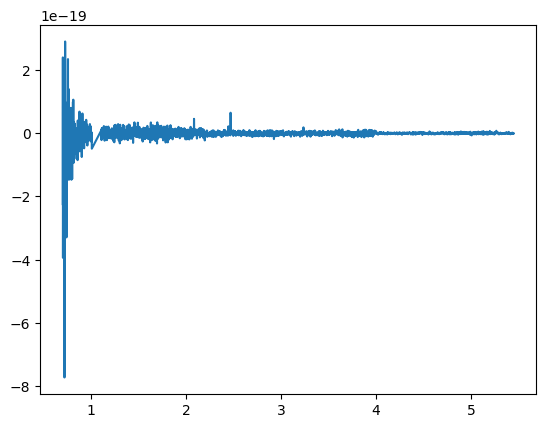

In [12]:
import random
rand = random.randint(0, len(combined_df) - 1)
plt.plot(combined_df.iloc[rand]['wavelength_high'],combined_df.iloc[rand]['flux_high_smoothed'])
plt.show()

# Removing NANs

In [13]:
def clean_flux_nans_within_each_spectrum(df):
    """
    Replace NaNs in flux, error, and wavelength arrays (low/high) with the median value
    of each individual spectrum. Cleans all key columns including flux_high_smoothed_err.

    Args:
        df: DataFrame with relevant spectral columns

    Returns:
        New DataFrame with NaNs replaced.
    """
    import numpy as np
    import pandas as pd

    cleaned_rows = []

    for _, row in df.iterrows():
        # Wavelengths
        w_lo = np.array(row["wavelength_low"])
        w_hi = np.array(row["wavelength_high"])
        
        # Fluxes
        f_lo = np.array(row["flux_low"])
        f_hi = np.array(row["flux_high"])
        f_hi_smoothed = np.array(row["flux_high_smoothed"])
        
        # Errors
        f_lo_err = np.array(row["flux_low_err"])
        f_hi_err = np.array(row["flux_high_err"])
        f_hi_smoothed_err = np.array(row["flux_high_smoothed_err"])

        # Helper to replace NaNs with median or 0 if no valid data
        def replace_nans(arr):
            valid = arr[~np.isnan(arr)]
            median = np.median(valid) if len(valid) > 0 else 0.0
            return np.where(np.isnan(arr), median, arr)

        # Clean each array
        w_lo_clean = replace_nans(w_lo)
        f_lo_clean = replace_nans(f_lo)
        f_lo_err_clean = replace_nans(f_lo_err)

        w_hi_clean = replace_nans(w_hi)
        f_hi_clean = replace_nans(f_hi)
        f_hi_err_clean = replace_nans(f_hi_err)
        f_hi_smoothed_clean = replace_nans(f_hi_smoothed)
        f_hi_smoothed_err_clean = replace_nans(f_hi_smoothed_err)

        cleaned_rows.append({
            "id": row["id"],
            "ra": row["ra"],
            "dec": row["dec"],
            "field": row["field"],
            "wavelength_low": w_lo_clean,
            "flux_low": f_lo_clean,
            "flux_low_err": f_lo_err_clean,
            "wavelength_high": w_hi_clean,
            "flux_high": f_hi_clean,
            "flux_high_err": f_hi_err_clean,
            "flux_high_smoothed": f_hi_smoothed_clean,
            "flux_high_smoothed_err": f_hi_smoothed_err_clean,
            "z": row["z"]
        })

    df_cleaned = pd.DataFrame(cleaned_rows)

    # Final safety check
    if df_cleaned.isnull().values.any():
        print("⚠ Warning: NaNs still found in cleaned DataFrame!")
    else:
        print("✅ All NaNs cleaned successfully.")

    return df_cleaned

In [14]:
combined_df = clean_flux_nans_within_each_spectrum(combined_df)

✅ All NaNs cleaned successfully.


In [15]:
combined_df.keys()

Index(['id', 'ra', 'dec', 'field', 'wavelength_low', 'flux_low',
       'flux_low_err', 'wavelength_high', 'flux_high', 'flux_high_err',
       'flux_high_smoothed', 'flux_high_smoothed_err', 'z'],
      dtype='object')

In [16]:
count_nan_stats(combined_df, "Cleaned Data")


=== Strict NaN Stats for Cleaned Data ===
Total rows: 2507
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field
✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z


# Augmenting by shifting the wavelength with a random number from a Gaussian Distribution + add optional noise

In [17]:
def augment_spectra_redshift(
    df,
    sigma=0.2,                # standard deviation of redshift shifts
    copies_per_row=4,
    seed=None,
    add_noise=True,
    noise_frac=0.01           # noise level relative to flux
):
    if seed is not None:
        np.random.seed(seed)

    augmented_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc= "Augmenting with redshifts"):
        #the low res part
        w_lo = np.array(row["wavelength_low"])
        f_lo = np.array(row["flux_low"])
        f_lo_err = np.array(row["flux_low_err"])
        
        #the high res part
        w_hi = np.array(row["wavelength_high"])
        f_hi = np.array(row["flux_high"])
        f_hi_smoothed = np.array(row["flux_high_smoothed"])
        f_hi_err = np.array(row["flux_high_err"])
        f_hi_smoothed_err = np.array(row["flux_high_smoothed_err"])
        
        base_id = row["id"]
        z_orig = row["z"]
        field_val = row["field"]

        for i in range(copies_per_row):
            z_shift = np.random.normal(0, sigma)
            z_new = z_orig + z_shift

            # moving back to rest frame
            w_rest_low = w_lo / (1 + z_orig)
            w_rest_high = w_hi / (1 + z_orig)

            # Redshift wavelengths to new redshift
            w_lo_z = w_rest_low * (1 + z_new)
            w_hi_z = w_rest_high * (1 + z_new)

            # Copy fluxes and errors
            f_lo_z = f_lo.copy()
            f_hi_z = f_hi.copy()
            f_hi_smoothed_z = f_hi_smoothed.copy()
            f_lo_err_z = f_lo_err.copy()
            f_hi_err_z = f_hi_err.copy()
            f_hi_smoothed_err_z = f_hi_smoothed_err.copy()

            if add_noise:
                sigma_lo = noise_frac * np.abs(f_lo_z) + 1e-23
                sigma_hi = noise_frac * np.abs(f_hi_z) + 1e-23
                sigma_hi_smoothed = noise_frac * np.abs(f_hi_smoothed_z) + 1e-23

                noise_lo = np.random.normal(0, sigma_lo)
                noise_hi = np.random.normal(0, sigma_hi)
                noise_hi_smoothed = np.random.normal(0, sigma_hi_smoothed)

                f_lo_z += noise_lo
                f_hi_z += noise_hi
                f_hi_smoothed_z += noise_hi_smoothed

                # Update errors in quadrature, safe from negatives
                f_lo_err_z = np.sqrt(f_lo_err_z**2 + sigma_lo**2)
                f_hi_err_z = np.sqrt(f_hi_err_z**2 + sigma_hi**2)
                f_hi_smoothed_err_z = np.sqrt(f_hi_smoothed_err_z**2 + sigma_hi_smoothed**2)

                #print("row")
                #print(f_lo_err_z[200])
                #print(f_hi_err_z[200])
                #print(f_hi_smoothed_err_z[200])

            augmented_rows.append({
                "id":                  f"{base_id}_zshift{i}_dz{z_shift:+.4f}",
                "ra":                  row["ra"],
                "dec":                 row["dec"],
                "field":               field_val,
                "z":                   z_new,

                "wavelength_low":      w_lo_z,
                "flux_low":            f_lo_z,
                "flux_low_err":        f_lo_err_z,

                "wavelength_high":     w_hi_z,
                "flux_high":           f_hi_z,
                "flux_high_smoothed":  f_hi_smoothed_z,
                "flux_high_err":       f_hi_err_z,
                "flux_high_smoothed_err": f_hi_smoothed_err_z,
            })

    df_aug = pd.DataFrame(augmented_rows)
    df_total = pd.concat([df, df_aug], ignore_index=True)

    print(f"Original size: {len(df)}  →  Augmented size: {len(df_total)}")
    return df_total

aug_df = augment_spectra_redshift(combined_df, sigma=0.3, copies_per_row=20, add_noise=True, noise_frac=0.1)

Augmenting with redshifts: 100%|██████████| 2507/2507 [00:19<00:00, 128.65it/s]


Original size: 2507  →  Augmented size: 52647


In [18]:
aug_df

,id,ra,dec,field,wavelength_low,flux_low,flux_low_err,wavelength_high,flux_high,flux_high_err,flux_high_smoothed,flux_high_smoothed_err,z
0,0,189.117202,62.221434,GOODS-North-Medium/HST,"[0.7507727559999999, 0.751772756, 0.7527727559...","[2.5385485067988796e-20, 2.6596687507557337e-2...","[6.146866955481448e-21, 6.1386010118082945e-21...","[0.7507727559999999, 0.751772756, 0.7527727559...","[-7.252436303683528e-20, -3.98387049593769e-20...","[1.666557305790514e-19, 1.461592358074945e-19,...","[-7.252436303683528e-20, -3.98387049593769e-20...","[1.666557305790514e-19, 1.461592358074945e-19,...",4.146842
1,1,189.108075,62.222050,GOODS-North-Medium/HST,"[0.7004999999999999, 0.7015, 0.702499999999999...","[3.214822116262436e-20, 3.2496529492389704e-20...","[1.1053711451154974e-20, 1.0734069755521752e-2...","[0.7004999999999999, 0.7015, 0.702499999999999...","[9.557155332946664e-20, 5.943679674654198e-19,...","[8.212688389040855e-19, 7.466082038943362e-19,...","[9.557155332946664e-20, 5.943679674654198e-19,...","[8.212688389040855e-19, 7.466082038943362e-19,...",3.972548
2,2,189.116947,62.222079,GOODS-North-Medium/HST,"[0.7145000079999999, 0.715500008, 0.7165000079...","[5.9302362580328166e-21, 5.316200268048604e-21...","[6.53116147222357e-21, 6.5409496435358644e-21,...","[0.7145000079999999, 0.715500008, 0.7165000079...","[-1.082665410773254e-18, -3.8724815070019355e-...","[4.1693278636631533e-19, 3.317507006639055e-19...","[-1.082665410773254e-18, -3.8724815070019355e-...","[4.1693278636631533e-19, 3.317507006639055e-19...",5.180958
3,3,189.127411,62.224434,GOODS-North-Medium/HST,"[0.796590964, 0.7975909639999998, 0.798590964,...","[3.854189289206667e-20, 3.845783686427403e-20,...","[6.812670461818058e-21, 6.747831129449629e-21,...","[0.796590964, 0.7975909639999998, 0.798590964,...","[4.4837673475938326e-20, -2.652193032011434e-2...","[7.31979825458488e-20, 6.617289751286978e-20, ...","[4.4837673475938326e-20, -2.652193032011434e-2...","[7.31979825458488e-20, 6.617289751286978e-20, ...",3.976253
4,4,189.110319,62.225442,GOODS-North-Medium/HST,"[0.7004999999999999, 0.7015, 0.702499999999999...","[-3.1607349335452587e-21, -1.7565047025606195e...","[1.1939113009830458e-20, 1.1897343345851179e-2...","[0.7004999999999999, 0.7015, 0.702499999999999...","[-3.8838171516320807e-19, -3.7561494574079363e...","[4.2940340117206425e-19, 8.550569218964737e-19...","[-3.8838171516320807e-19, -3.7561494574079363e...","[4.2940340117206425e-19, 8.550569218964737e-19...",5.347199
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52642,4449_zshift15_dz+1.0043,53.216656,-27.783790,GOODS-South-Medium/JWST,"[0.9593175191567583, 0.960686994558838, 0.9620...","[4.461228484785593e-20, 4.5287175336777833e-20...","[8.986228667267391e-21, 8.86139350103822e-21, ...","[0.9593175191567583, 0.960686994558838, 0.9620...","[-2.7323781101140373e-19, -2.592091864631974e-...","[7.197783787466721e-19, 4.258469406184194e-19,...","[-2.8357397571628585e-19, -2.288008723005743e-...","[7.197783787466721e-19, 4.258469406184194e-19,...",2.722503
52643,4449_zshift16_dz-0.6556,53.216656,-27.783790,GOODS-South-Medium/JWST,"[0.5315522284967665, 0.5323110468101095, 0.533...","[4.442678254672401e-20, 4.9344498030385326e-20...","[8.986228667267391e-21, 8.86139350103822e-21, ...","[0.5315522284967665, 0.5323110468101095, 0.533...","[-3.614406904390884e-19, -2.286527698190873e-1...","[7.197783787466721e-19, 4.258469406184194e-19,...","[-2.825280476180529e-19, -2.9482181497063287e-...","[7.197783787466721e-19, 4.258469406184194e-19,...",1.062617
52644,4449_zshift17_dz+0.2918,53.216656,-27.783790,GOODS-South-Medium/JWST,"[0.7756866873156741, 0.7767940202026345, 0.777...","[4.764122056774474e-20, 4.7202474504182477e-20...","[8.986228667267391e-21, 8.86139350103822e-21, ...","[0.7756866873156741, 0.7767940202026345, 0.777...","[-2.9331393109670745e-19, -2.672676632621495e-...","[7.197783787466721e-19, 4.258469406184194e-19,...","[-3.0899055855690158e-19, -2.312062948082648e-...","[

In [19]:
count_nan_stats(aug_df, "Augmented Data Frame")


=== Strict NaN Stats for Augmented Data Frame ===
Total rows: 52647
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field
✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z


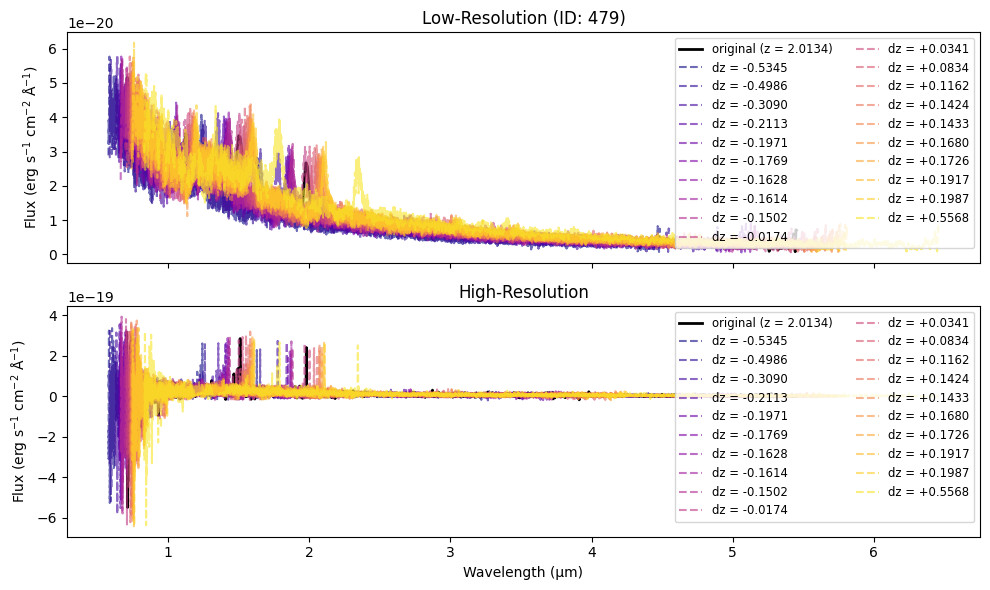

In [20]:
def plot_random_spectra_gaussian_highlight(original_df, augmented_df):
    """
    Randomly select one original spectrum from original_df and plot it together
    with all of its redshifted augmentations from augmented_df.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # 1) Pick a random original row
    row = original_df.sample(n=1).iloc[0]
    base_id = str(row["id"])
    z_original = row.get("z", None)

    # 2) Select all augmentations that match this base_id
    mask = augmented_df["id"].astype(str).str.startswith(base_id + "_zshift")
    aug = augmented_df[mask].copy()
    if aug.empty:
        raise ValueError(f"No augmentations found for ID {base_id}")

    # 3) Parse dz from ID
    def _parse_dz(id_str):
        try:
            dz_part = id_str.split("_dz")[-1]
            return float(dz_part)
        except:
            return np.nan

    aug["dz_val"] = aug["id"].astype(str).apply(_parse_dz)
    aug.dropna(subset=["dz_val"], inplace=True)
    aug.sort_values("dz_val", inplace=True)

    # 4) Set up a color map
    cmap = plt.get_cmap("plasma")
    colors = [cmap(i / len(aug)) for i in range(len(aug))]

    # 5) Create two stacked subplots
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Label for original including z
    original_label = f"original (z = {z_original:.4f})" if z_original is not None else "original"

    # Low-resolution panel
    axs[0].plot(
        row["wavelength_low"], row["flux_low"],
        color="k", lw=2, label=original_label
    )
    for i, a in enumerate(aug.itertuples()):
        axs[0].plot(
            a.wavelength_low, a.flux_low,
            color=colors[i], linestyle="--", alpha=0.6,
            label=f"dz = {a.dz_val:+.4f}"
        )
    axs[0].set_title(f"Low-Resolution (ID: {base_id})")
    axs[0].set_ylabel("Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    axs[0].legend(ncol=2, fontsize="small", loc="upper right")

    # High-resolution panel
    axs[1].plot(
        row["wavelength_high"], row["flux_high"],
        color="k", lw=2, label=original_label
    )
    for i, a in enumerate(aug.itertuples()):
        axs[1].plot(
            a.wavelength_high, a.flux_high,
            color=colors[i], linestyle="--", alpha=0.6,
            label=f"dz = {a.dz_val:+.4f}"
        )
    axs[1].set_title("High-Resolution")
    axs[1].set_xlabel("Wavelength (μm)")
    axs[1].set_ylabel("Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    axs[1].legend(ncol=2, fontsize="small", loc="upper right")

    plt.tight_layout()
    plt.savefig("../plots/augmentation_DR4.png")
    plt.show()

plot_random_spectra_gaussian_highlight(combined_df, aug_df)

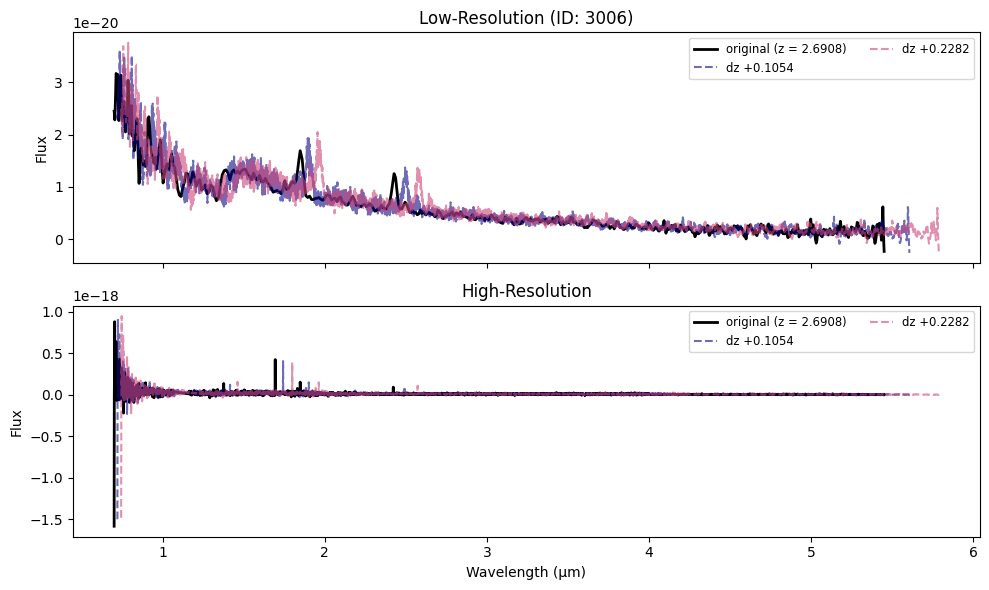

In [21]:
def plot_random_spectra_gaussian_highlight_n(original_df, augmented_df, n_to_draw=None):
    """
    Randomly select one original spectrum from original_df and plot it together
    with a random subset (or all) of its redshifted augmentations from augmented_df.

    Args:
        original_df: DataFrame with columns like ['id', 'wavelength_low', 'flux_low',
                     'wavelength_high', 'flux_high', 'z']
        augmented_df: DataFrame whose 'id' entries are of the form
                     "{base_id}_zshift{i}_dz{z_shift:+.4f}"
        n_to_draw: int or None. If int, plot that many random augmentations.
                   If None, plot all available. If int > available, raises ValueError.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # 1) Pick a random original row
    row = original_df.sample(n=1).iloc[0]
    base_id = str(row["id"])
    z_original = row.get("z", None)

    # 2) Select all augmentations that match this base_id
    mask = augmented_df["id"].astype(str).str.startswith(base_id + "_zshift")
    aug = augmented_df[mask].copy()
    if aug.empty:
        raise ValueError(f"No augmentations found for ID {base_id}")

    # 3) Parse and sort by dz (shift)
    def _parse_dz(id_str):
        try:
            dz_part = id_str.split("_dz")[-1]
            return float(dz_part)
        except:
            return np.nan

    aug["dz_val"] = aug["id"].astype(str).apply(_parse_dz)
    aug.dropna(subset=["dz_val"], inplace=True)
    aug.sort_values("dz_val", inplace=True)

    # 4) Subsample if requested
    total = len(aug)
    if n_to_draw is not None:
        if not isinstance(n_to_draw, int) or n_to_draw < 1:
            raise ValueError(f"n_to_draw must be a positive integer or None, got {n_to_draw!r}.")
        if n_to_draw > total:
            raise ValueError(f"Requested {n_to_draw} augmentations, but only {total} available.")
        aug = aug.sample(n=n_to_draw)
        aug.sort_values("dz_val", inplace=True)

    # 5) Set up a color map
    cmap = plt.get_cmap("plasma")
    colors = [cmap(i / len(aug)) for i in range(len(aug))]

    # Label for original including z
    original_label = f"original (z = {z_original:.4f})" if z_original is not None else "original"

    # 6) Create two stacked subplots
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Low-resolution panel
    axs[0].plot(
        row["wavelength_low"], row["flux_low"],
        color="k", lw=2, label=original_label
    )
    for i, a in enumerate(aug.itertuples()):
        axs[0].plot(
            a.wavelength_low, a.flux_low,
            color=colors[i], linestyle="--", alpha=0.6,
            label=f"dz {a.dz_val:+.4f}"
        )
    axs[0].set_title(f"Low-Resolution (ID: {base_id})")
    axs[0].set_ylabel("Flux")
    axs[0].legend(ncol=2, fontsize="small", loc="upper right")

    # High-resolution panel
    axs[1].plot(
        row["wavelength_high"], row["flux_high"],
        color="k", lw=2, label=original_label
    )
    for i, a in enumerate(aug.itertuples()):
        axs[1].plot(
            a.wavelength_high, a.flux_high,
            color=colors[i], linestyle="--", alpha=0.6,
            label=f"dz {a.dz_val:+.4f}"
        )
    axs[1].set_title("High-Resolution")
    axs[1].set_xlabel("Wavelength (μm)")
    axs[1].set_ylabel("Flux")
    axs[1].legend(ncol=2, fontsize="small", loc="upper right")

    plt.tight_layout()
    plt.show()
plot_random_spectra_gaussian_highlight_n(combined_df, aug_df, n_to_draw=2)

In [22]:
def check_spectra_coverage(df, wl_min=1.0, wl_max=5.0):
    """
    Check if all spectra in the DataFrame cover the specified wavelength range
    in both low and high resolution.

    Args:
        df: DataFrame with columns 'wavelength_low' and 'wavelength_high'
        wl_min: lower wavelength bound (microns)
        wl_max: upper wavelength bound (microns)

    Returns:
        A boolean: True if all spectra cover the range, False otherwise.
        A DataFrame of problematic rows if any.
    """
    missing_rows = []

    for _, row in df.iterrows():
        w_lo = np.array(row["wavelength_low"])
        w_hi = np.array(row["wavelength_high"])

        # Check low-res
        if (w_lo.min() > wl_min) or (w_lo.max() < wl_max):
            missing_rows.append(row)
            continue  # no need to check high-res if low-res already fails

        # Check high-res
        if (w_hi.min() > wl_min) or (w_hi.max() < wl_max):
            missing_rows.append(row)

    if missing_rows:
        # Return False and a DataFrame of problematic rows
        problem_df = pd.DataFrame(missing_rows)
        return False, problem_df
    else:
        return True, None
    
# Check coverage for the full range
coverage, problem_df = check_spectra_coverage(aug_df, wl_min=1.0, wl_max=5.0)

In [23]:
coverage

False

In [24]:
aug_df.keys()

Index(['id', 'ra', 'dec', 'field', 'wavelength_low', 'flux_low',
       'flux_low_err', 'wavelength_high', 'flux_high', 'flux_high_err',
       'flux_high_smoothed', 'flux_high_smoothed_err', 'z'],
      dtype='object')

In [25]:
def trim_spectra_to_range(df, wl_min=1.0, wl_max=5.0):
    """
    Trim each spectrum in the DataFrame to the specified wavelength range.
    Applies to both low and high resolution arrays + errors + smoothed.
    
    Args:
        df: DataFrame with required columns
        wl_min: lower wavelength bound (microns)
        wl_max: upper wavelength bound (microns)
    
    Returns:
        Trimmed DataFrame.
    """
    import numpy as np
    import pandas as pd

    trimmed_rows = []

    for _, row in df.iterrows():
        # --- Low-res ---
        w_lo = np.array(row["wavelength_low"])
        f_lo = np.array(row["flux_low"])
        f_lo_err = np.array(row["flux_low_err"])
        mask_lo = (w_lo >= wl_min) & (w_lo <= wl_max)
        w_lo_trimmed = w_lo[mask_lo]
        f_lo_trimmed = f_lo[mask_lo]
        f_lo_err_trimmed = f_lo_err[mask_lo]

        # --- High-res ---
        w_hi = np.array(row["wavelength_high"])
        f_hi = np.array(row["flux_high"])
        f_hi_err = np.array(row["flux_high_err"])
        f_hi_smoothed = np.array(row["flux_high_smoothed"])
        f_hi_smoothed_err = np.array(row["flux_high_smoothed_err"])
        mask_hi = (w_hi >= wl_min) & (w_hi <= wl_max)
        w_hi_trimmed = w_hi[mask_hi]
        f_hi_trimmed = f_hi[mask_hi]
        f_hi_err_trimmed = f_hi_err[mask_hi]
        f_hi_smoothed_trimmed = f_hi_smoothed[mask_hi]
        f_hi_smoothed_err_trimmed = f_hi_smoothed_err[mask_hi]

        trimmed_rows.append({
            "id": row["id"],
            "ra": row["ra"],
            "dec": row["dec"],
            "field": row["field"],
            "wavelength_low": w_lo_trimmed,
            "flux_low": f_lo_trimmed,
            "flux_low_err": f_lo_err_trimmed,
            "wavelength_high": w_hi_trimmed,
            "flux_high": f_hi_trimmed,
            "flux_high_err": f_hi_err_trimmed,
            "flux_high_smoothed": f_hi_smoothed_trimmed,
            "flux_high_smoothed_err": f_hi_smoothed_err_trimmed,
            "z": row["z"]
        })

    return pd.DataFrame(trimmed_rows)

trimmed_df = trim_spectra_to_range(aug_df, wl_min=1.0, wl_max=5.0)


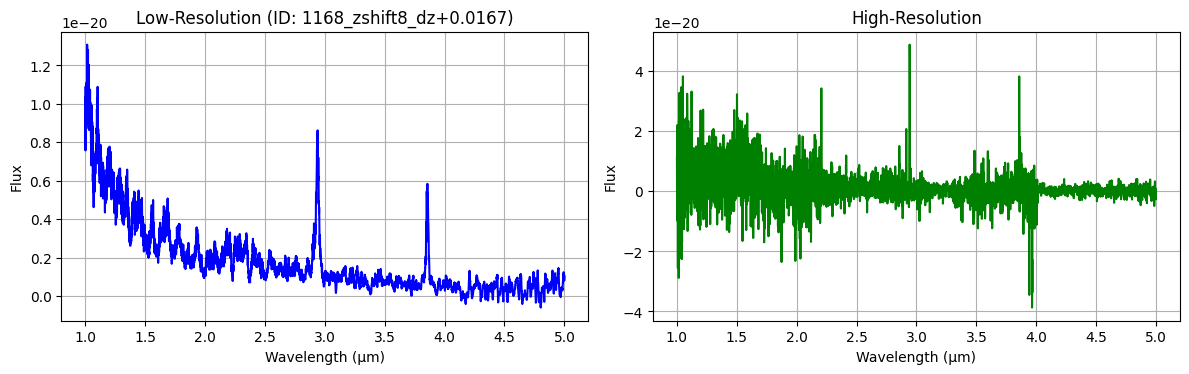

In [26]:
def plot_random_trimmed_spectrum(trimmed_df):
    """
    Pick a random spectrum from the trimmed DataFrame and plot its low and high resolution.

    Args:
        trimmed_df: DataFrame with trimmed 'wavelength_low', 'flux_low',
                    'wavelength_high', 'flux_high'
    """
    # 1. Pick a random row
    row = trimmed_df.sample(n=1).iloc[0]
    base_id = row["id"]

    # 2. Create side-by-side subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # 3. Plot low-resolution spectrum
    axs[0].plot(row["wavelength_low"], row["flux_low"], color='blue')
    axs[0].set_title(f"Low-Resolution (ID: {base_id})")
    axs[0].set_xlabel("Wavelength (μm)")
    axs[0].set_ylabel("Flux")
    axs[0].grid(True)

    # 4. Plot high-resolution spectrum
    axs[1].plot(row["wavelength_high"], row["flux_high"], color='green')
    axs[1].set_title("High-Resolution")
    axs[1].set_xlabel("Wavelength (μm)")
    axs[1].set_ylabel("Flux")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_random_trimmed_spectrum(trimmed_df)

=== Low-Resolution Spectra ===
Min length:      2201
Max length:      4362
Mean length:     3978.9
Median length:   4000.0
90th percentile: 4306.0
95th percentile: 4338.0

=== High-Resolution Spectra ===
Min length:      2201
Max length:      4362
Mean length:     3978.9
Median length:   4000.0
90th percentile: 4306.0
95th percentile: 4338.0


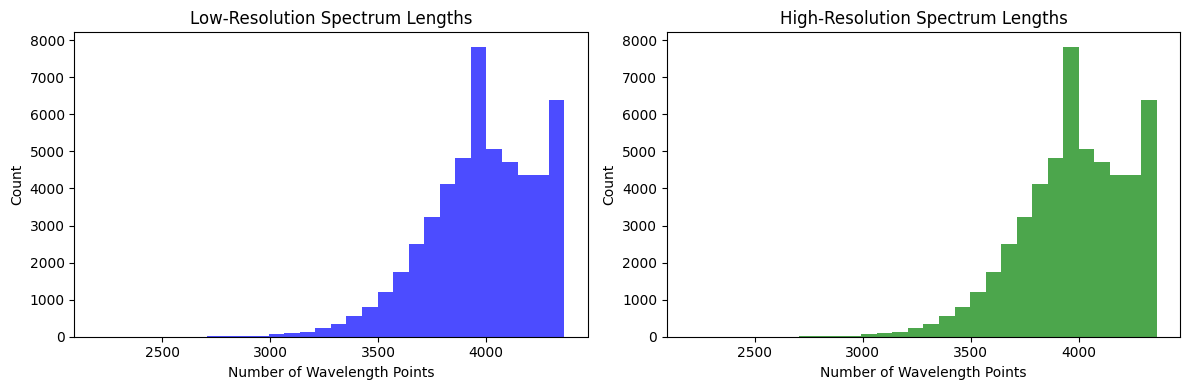

In [27]:
# Compute lengths of each spectrum
low_lengths = trimmed_df["wavelength_low"].apply(len)
high_lengths = trimmed_df["wavelength_high"].apply(len)

# Print stats
print("=== Low-Resolution Spectra ===")
print(f"Min length:      {low_lengths.min()}")
print(f"Max length:      {low_lengths.max()}")
print(f"Mean length:     {low_lengths.mean():.1f}")
print(f"Median length:   {low_lengths.median()}")
print(f"90th percentile: {np.percentile(low_lengths, 90):.1f}")
print(f"95th percentile: {np.percentile(low_lengths, 95):.1f}")
print()

print("=== High-Resolution Spectra ===")
print(f"Min length:      {high_lengths.min()}")
print(f"Max length:      {high_lengths.max()}")
print(f"Mean length:     {high_lengths.mean():.1f}")
print(f"Median length:   {high_lengths.median()}")
print(f"90th percentile: {np.percentile(high_lengths, 90):.1f}")
print(f"95th percentile: {np.percentile(high_lengths, 95):.1f}")

# Plot histograms
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(low_lengths, bins=30, color='blue', alpha=0.7)
axs[0].set_title("Low-Resolution Spectrum Lengths")
axs[0].set_xlabel("Number of Wavelength Points")
axs[0].set_ylabel("Count")

axs[1].hist(high_lengths, bins=30, color='green', alpha=0.7)
axs[1].set_title("High-Resolution Spectrum Lengths")
axs[1].set_xlabel("Number of Wavelength Points")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [28]:
count_nan_stats(trimmed_df, "Trimmed Spectra")


=== Strict NaN Stats for Trimmed Spectra ===
Total rows: 52647
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field


✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z


In [29]:
def interpolate_spectra_to_fixed_grids(df, wl_min=1.0, wl_max=5.0, n_lo=500, n_hi=2500):
    """
    Interpolate all spectra in the DataFrame onto fixed-length grids over [wl_min, wl_max],
    including flux, error, and smoothed arrays.
    
    NaNs from interpolation are replaced with the median of that spectrum.
    
    Returns:
        New DataFrame with interpolated and cleaned spectra.
    """
    import numpy as np
    import pandas as pd
    from scipy.interpolate import interp1d

    wl_lo_grid = np.linspace(wl_min, wl_max, n_lo)
    wl_hi_grid = np.linspace(wl_min, wl_max, n_hi)

    rows = []
    for _, row in df.iterrows():
        w_lo = np.array(row["wavelength_low"])
        f_lo = np.array(row["flux_low"])
        f_lo_err = np.array(row["flux_low_err"])

        w_hi = np.array(row["wavelength_high"])
        f_hi = np.array(row["flux_high"])
        f_hi_err = np.array(row["flux_high_err"])
        f_hi_smoothed = np.array(row["flux_high_smoothed"])
        f_hi_smoothed_err = np.array(row["flux_high_smoothed_err"])

        if len(w_lo) < 2 or len(w_hi) < 2:
            continue

        # Helper for interpolation + median fill
        def interpolate_and_fill(x, y, grid):
            f = interp1d(x, y, kind='linear', bounds_error=False, fill_value=np.nan)
            y_new = f(grid)
            if np.isnan(y_new).any():
                median_val = np.nanmedian(y_new)
                y_new = np.where(np.isnan(y_new), median_val, y_new)
            return y_new

        # Low-res
        f_lo_interp = interpolate_and_fill(w_lo, f_lo, wl_lo_grid)
        f_lo_err_interp = interpolate_and_fill(w_lo, f_lo_err, wl_lo_grid)

        # High-res
        f_hi_interp = interpolate_and_fill(w_hi, f_hi, wl_hi_grid)
        f_hi_err_interp = interpolate_and_fill(w_hi, f_hi_err, wl_hi_grid)
        f_hi_smoothed_interp = interpolate_and_fill(w_hi, f_hi_smoothed, wl_hi_grid)
        f_hi_smoothed_err_interp = interpolate_and_fill(w_hi, f_hi_smoothed_err, wl_hi_grid)

        rows.append({
            "id": row["id"],
            "ra": row["ra"],
            "dec": row["dec"],
            "field": row["field"],
            "z": row["z"],
            "wavelength_low": wl_lo_grid,
            "flux_low": f_lo_interp,
            "flux_low_err": f_lo_err_interp,
            "wavelength_high": wl_hi_grid,
            "flux_high": f_hi_interp,
            "flux_high_err": f_hi_err_interp,
            "flux_high_smoothed": f_hi_smoothed_interp,
            "flux_high_smoothed_err": f_hi_smoothed_err_interp
        })

    return pd.DataFrame(rows)

interpolated_df = interpolate_spectra_to_fixed_grids(trimmed_df, n_lo=500, n_hi=2500)
count_nan_stats(interpolated_df, "Interpolated, 500 & 2500 points")



=== Strict NaN Stats for Interpolated, 500 & 2500 points ===
Total rows: 52647
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field
✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z


In [30]:
def interpolate_spectra_to_fixed_grids(df, wl_min=1.0, wl_max=5.0, n_points=2500):
    """
    Interpolates both low-res and high-res spectra + errors + smoothed to the same fixed grid 
    and retains all key columns.

    Args:
        df: Input DataFrame
        wl_min: Minimum wavelength for interpolation
        wl_max: Maximum wavelength for interpolation
        n_points: Number of wavelength samples (same for both low and high)

    Returns:
        A new DataFrame with interpolated columns.
    """
    import numpy as np
    import pandas as pd
    from scipy.interpolate import interp1d

    common_grid = np.linspace(wl_min, wl_max, n_points)
    rows = []

    def interpolate_and_fill(x, y):
        f = interp1d(x, y, kind='linear', bounds_error=False, fill_value=np.nan)
        y_interp = f(common_grid)
        if np.isnan(y_interp).any():
            median_val = np.nanmedian(y_interp)
            y_interp = np.where(np.isnan(y_interp), median_val, y_interp)
        return y_interp

    for _, row in df.iterrows():
        w_lo = np.array(row["wavelength_low"])
        f_lo = np.array(row["flux_low"])
        f_lo_err = np.array(row["flux_low_err"])

        w_hi = np.array(row["wavelength_high"])
        f_hi = np.array(row["flux_high"])
        f_hi_err = np.array(row["flux_high_err"])
        f_hi_smoothed = np.array(row["flux_high_smoothed"])
        f_hi_smoothed_err = np.array(row["flux_high_smoothed_err"])

        if len(w_lo) < 2 or len(w_hi) < 2:
            continue

        # Interpolate each array
        f_lo_interp = interpolate_and_fill(w_lo, f_lo)
        f_lo_err_interp = interpolate_and_fill(w_lo, f_lo_err)
        f_hi_interp = interpolate_and_fill(w_hi, f_hi)
        f_hi_err_interp = interpolate_and_fill(w_hi, f_hi_err)
        f_hi_smoothed_interp = interpolate_and_fill(w_hi, f_hi_smoothed)
        f_hi_smoothed_err_interp = interpolate_and_fill(w_hi, f_hi_smoothed_err)

        rows.append({
            "id": row["id"],
            "ra": row["ra"],
            "dec": row["dec"],
            "field": row["field"],
            "z": row["z"],
            "wavelength_low": common_grid,
            "flux_low": f_lo_interp,
            "flux_low_err": f_lo_err_interp,
            "wavelength_high": common_grid,
            "flux_high": f_hi_interp,
            "flux_high_err": f_hi_err_interp,
            "flux_high_smoothed": f_hi_smoothed_interp,
            "flux_high_smoothed_err": f_hi_smoothed_err_interp
        })

    return pd.DataFrame(rows)
interpolated_df = interpolate_spectra_to_fixed_grids(trimmed_df)
count_nan_stats(interpolated_df, "Interpolated, 2500 points")



=== Strict NaN Stats for Interpolated, 2500 points ===
Total rows: 52647
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field
✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z


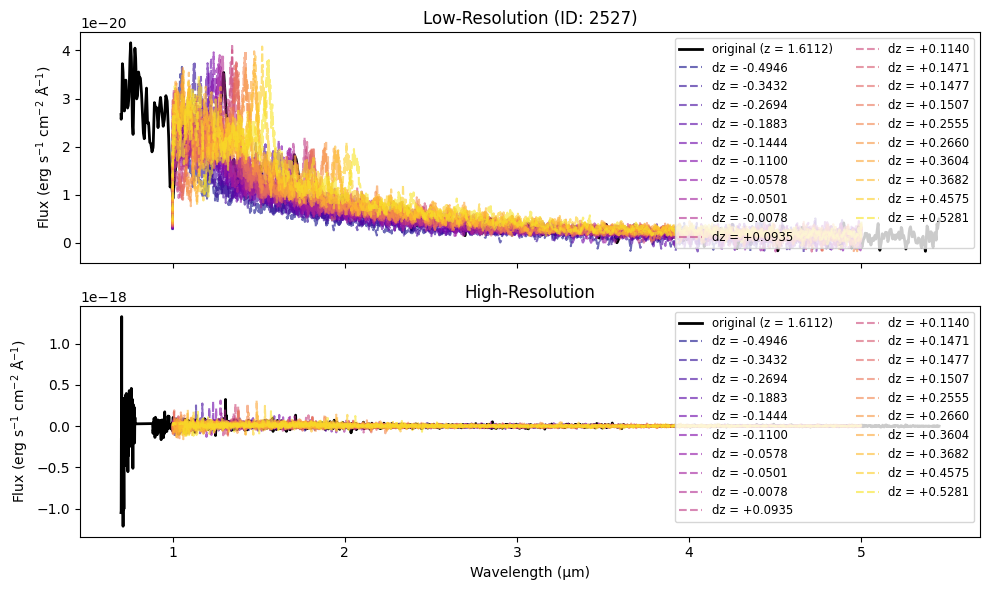

In [31]:
plot_random_spectra_gaussian_highlight(combined_df,interpolated_df)

# Save :D

In [32]:
count_nan_stats(combined_df, "Combined (original)")
count_nan_stats(aug_df, "Augmented")
count_nan_stats(trimmed_df, "Trimmed to 1–5 μm")
count_nan_stats(interpolated_df, "Interpolated 2500")


=== Strict NaN Stats for Combined (original) ===
Total rows: 2507
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field
✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z

=== Strict NaN Stats for Augmented ===
Total rows: 52647
✅ No NaNs in column: ra
✅ No NaNs in column: dec
✅ No NaNs in column: field
✅ No NaNs in column: wavelength_low
✅ No NaNs in column: flux_low
✅ No NaNs in column: flux_low_err
✅ No NaNs in column: wavelength_high
✅ No NaNs in column: flux_high
✅ No NaNs in column: flux_high_smoothed
✅ No NaNs in column: flux_high_err
✅ No NaNs in column: flux_high_smoothed_err
✅ No NaNs in column: z

=== Strict NaN Stats for Trimmed to 1–5 μm ===
Total rows: 52647
✅ No NaNs in column: ra
✅ No NaNs in 

In [33]:
interpolated_df.keys()

Index(['id', 'ra', 'dec', 'field', 'z', 'wavelength_low', 'flux_low',
       'flux_low_err', 'wavelength_high', 'flux_high', 'flux_high_err',
       'flux_high_smoothed', 'flux_high_smoothed_err'],
      dtype='object')

In [34]:

# Extract arrays
flux_low_array = np.stack(interpolated_df["flux_low"].values)
flux_low_err_array = np.stack(interpolated_df["flux_low_err"].values)
flux_high_array = np.stack(interpolated_df["flux_high"].values)
flux_high_err_array = np.stack(interpolated_df["flux_high_err"].values)
flux_high_smoothed_array = np.stack(interpolated_df["flux_high_smoothed"].values)
flux_high_smoothed_err_array = np.stack(interpolated_df["flux_high_smoothed_err"].values)

ids = np.array(interpolated_df["id"].values)
ra = np.array(interpolated_df["ra"].values)
dec = np.array(interpolated_df["dec"].values)
field = np.array(interpolated_df["field"].values)
z = np.array(interpolated_df["z"].values)

# Save wavelength grids (assuming same for all rows)
wavelength_low = interpolated_df["wavelength_low"].iloc[0]
wavelength_high = interpolated_df["wavelength_high"].iloc[0]

# Save everything to npz
np.savez_compressed(
    "../data/spectra_dataset_2500_DR4.npz",
    flux_low=flux_low_array,
    flux_low_err=flux_low_err_array,
    flux_high=flux_high_array,
    flux_high_err=flux_high_err_array,
    flux_high_smoothed=flux_high_smoothed_array,
    flux_high_smoothed_err=flux_high_smoothed_err_array,
    id=ids,
    ra=ra,
    dec=dec,
    field=field,
    z=z,
    wavelength_low=wavelength_low,
    wavelength_high=wavelength_high
)

print("✅ Saved all required arrays to spectra_dataset_2500_DR4.npz")


✅ Saved all required arrays to spectra_dataset_2500_DR4.npz


In [35]:
path = "../data/spectra_dataset_2500_DR4.npz"
data = np.load(path, allow_pickle=True)

keys = [
    "wavelength_low", "flux_low", "flux_low_err",
    "wavelength_high", "flux_high", "flux_high_err",
    "flux_high_smoothed", "flux_high_smoothed_err"
]

def lengths_from(arr):
    """Return a list of per-item lengths even for ragged/object arrays."""
    if arr.ndim == 1 and arr.dtype != object:
        # a single shared wavelength grid, e.g. shape (2500,)
        return [arr.shape[0]]
    if arr.ndim == 2 and arr.dtype != object:
        # regular 2D array [N, L]
        return [arr.shape[1]]
    # object or ragged: compute per-element length
    return [len(x) for x in arr]

def has_nans(arr):
    if arr.dtype == object:
        return any(np.isnan(x).any() for x in arr)
    return np.isnan(arr).any()

report = {}

print("=== Shape/length checks ===")
for k in keys:
    arr = data[k]
    Ls = lengths_from(arr)
    uniq = sorted(set(Ls))
    ok_2500 = (uniq == [2500])
    print(f"{k:25s} shape={arr.shape} dtype={arr.dtype} unique_lengths={uniq}  -> all_2500={ok_2500}")
    report[k] = {"unique_lengths": uniq, "all_2500": ok_2500, "has_nans": has_nans(arr)}

# Cross-check wavelength grids (if stored as single shared vectors)
wl_lo = data["wavelength_low"]
wl_hi = data["wavelength_high"]
same_grid = False
if wl_lo.ndim == 1 and wl_hi.ndim == 1 and wl_lo.shape == wl_hi.shape:
    same_grid = np.allclose(wl_lo, wl_hi, rtol=0, atol=0)
print(f"\nWavelength grids identical (low vs high): {same_grid}")

# Sanity: each flux/error shares the same length as wavelength_high
def length_of_grid(arr):
    return arr.shape[0] if arr.ndim == 1 else (arr.shape[1] if arr.ndim == 2 else None)

L_grid = length_of_grid(wl_hi)
grid_ok = True
for k in ["flux_high", "flux_high_err", "flux_high_smoothed", "flux_high_smoothed_err",
          "flux_low", "flux_low_err"]:
    arr = data[k]
    Lk = length_of_grid(arr)
    match = (Lk == L_grid == 2500)
    print(f"{k:25s} matches wavelength length 2500: {match}")
    grid_ok &= bool(match)

# NaN summary
print("\n=== NaN summary ===")
for k in keys:
    print(f"{k:25s} has_nans={report[k]['has_nans']}")

# Final verdict
all_ok = all(report[k]["all_2500"] for k in keys) and same_grid and grid_ok
print(f"\nFINAL: all arrays length 2500, grids identical, and shapes consistent: {all_ok}")

=== Shape/length checks ===
wavelength_low            shape=(2500,) dtype=float64 unique_lengths=[2500]  -> all_2500=True
flux_low                  shape=(52647, 2500) dtype=float64 unique_lengths=[2500]  -> all_2500=True
flux_low_err              shape=(52647, 2500) dtype=float64 unique_lengths=[2500]  -> all_2500=True
wavelength_high           shape=(2500,) dtype=float64 unique_lengths=[2500]  -> all_2500=True
flux_high                 shape=(52647, 2500) dtype=float64 unique_lengths=[2500]  -> all_2500=True
flux_high_err             shape=(52647, 2500) dtype=float64 unique_lengths=[2500]  -> all_2500=True
flux_high_smoothed        shape=(52647, 2500) dtype=float64 unique_lengths=[2500]  -> all_2500=True
flux_high_smoothed_err    shape=(52647, 2500) dtype=float64 unique_lengths=[2500]  -> all_2500=True

Wavelength grids identical (low vs high): True
flux_high                 matches wavelength length 2500: True
flux_high_err             matches wavelength length 2500: True
flux_high_

In [36]:
interpolated_df.iloc[0]

id                                                                        0
ra                                                               189.117202
dec                                                               62.221434
field                                                GOODS-North-Medium/HST
z                                                                  4.146842
wavelength_low            [1.0, 1.0016006402561024, 1.0032012805122048, ...
flux_low                  [2.4086044981334584e-21, 1.628244373345497e-20...
flux_low_err              [6.826850897437462e-22, 3.3616729018830483e-21...
wavelength_high           [1.0, 1.0016006402561024, 1.0032012805122048, ...
flux_high                 [1.9098401555767373e-21, 3.842693132757879e-20...
flux_high_err             [5.362224322210539e-21, 2.6848684765498133e-20...
flux_high_smoothed        [1.9098401555767373e-21, 3.842693132757879e-20...
flux_high_smoothed_err    [5.362224322210539e-21, 2.6848684765498133e-20...
Name: 0, dty

In [37]:
def plot_augmented_spectrum_by_id(original_df, augmented_df, obj_id=None):
    """
    Plot the low-resolution and high-resolution spectra for a given object ID.
    If obj_id is None, a random object from original_df is selected.

    Includes all its Gaussian-redshift augmentations from augmented_df.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # === PLOT STYLE ===
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Georgia"],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8
    })

    # -------------------------------------
    # 1) Pick row by ID or random
    # -------------------------------------
    if obj_id is None:
        row = original_df.sample(n=1).iloc[0]
    else:
        matches = original_df[original_df["id"] == obj_id]
        if len(matches) == 0:
            raise ValueError(f"ID {obj_id} not found in original_df")
        row = matches.iloc[0]

    base_id = str(row["id"])
    ra = row["ra"]
    dec = row["dec"]
    field = row["field"]
    z_original = row.get("z", None)

    # -------------------------------------
    # 2) Find augmentations for that ID
    # -------------------------------------
    mask = augmented_df["id"].astype(str).str.startswith(base_id + "_zshift")
    aug = augmented_df[mask].copy()

    if aug.empty:
        raise ValueError(f"No augmentations found for ID {base_id}")

    def _parse_dz(id_str):
        try:
            return float(id_str.split("_dz")[-1])
        except:
            return np.nan

    aug["dz_val"] = aug["id"].astype(str).apply(_parse_dz)
    aug.dropna(subset=["dz_val"], inplace=True)
    aug.sort_values("dz_val", inplace=True)

    # -------------------------------------
    # 3) Color scheme
    # -------------------------------------
    cmap = plt.get_cmap("plasma")
    colors = [cmap(i / len(aug)) for i in range(len(aug))]

    # -------------------------------------
    # 4) Plot figure
    # -------------------------------------
    fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    # Meta info
    original_label = (
        f"original (z = {z_original:.4f})"
        if z_original is not None else "original"
    )

    meta_title = (
        f"ID = {base_id} — RA = {ra:.6f}°, Dec = {dec:.6f}°, Field = {field}"
    )

    # ==== SUPERTITLE (closer + same font style) ====
    fig.suptitle(
        meta_title,
        fontsize=11,
        fontweight="regular",
        y=0.9             # move supertitle DOWN
    )

    # ---------- LOW RES ----------
    axs[0].plot(
        row["wavelength_low"],
        row["flux_low"],
        color="k",
        lw=1.2,             # thinner original line
        label=original_label
    )

    for i, a in enumerate(aug.itertuples()):
        axs[0].plot(
            a.wavelength_low, a.flux_low,
            color=colors[i], linestyle="--", alpha=0.6,
            label=f"dz = {a.dz_val:+.4f}"
        )

    axs[0].set_title("Low-Resolution")
    axs[0].set_ylabel("Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    axs[0].legend(ncol=2, fontsize="small", loc="upper right")

    # ---------- HIGH RES ----------
    axs[1].plot(
        row["wavelength_high"],
        row["flux_high"],
        color="k",
        lw=1.2,             # thinner original spectrum
        label=original_label
    )

    for i, a in enumerate(aug.itertuples()):
        axs[1].plot(
            a.wavelength_high, a.flux_high,
            color=colors[i], linestyle="--", alpha=0.6,
            label=f"dz = {a.dz_val:+.4f}"
        )

    axs[1].set_title("High-Resolution")
    axs[1].set_xlabel("Wavelength (μm)")
    axs[1].set_ylabel("Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    axs[1].legend(ncol=2, fontsize="small", loc="upper right")

    # ==== REDUCE GAP UNDER SUPERTITLE ====
    plt.tight_layout(rect=[0, 0, 1, 0.93])   # pull plots upward

    plt.savefig("../plots/augmentation_DR4.png",
            dpi=450,
            bbox_inches="tight",
            pad_inches=0.05)
    plt.show()

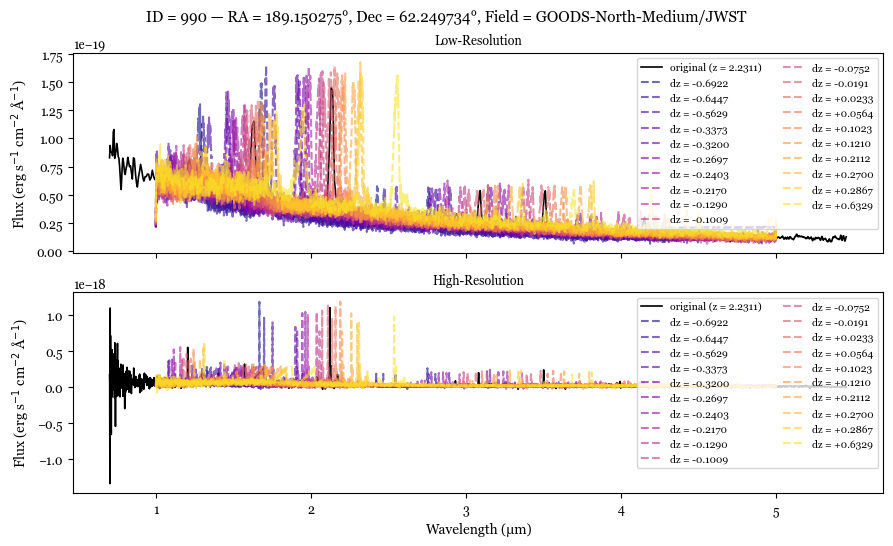

In [38]:
plot_augmented_spectrum_by_id(combined_df, interpolated_df, obj_id=990)